
DATASET SUMMARY

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     5783 non-null   int64  
 1   NCT Number               5783 non-null   object 
 2   Title                    5783 non-null   object 
 3   Acronym                  2480 non-null   object 
 4   Status                   5783 non-null   object 
 5   Study Results            5783 non-null   object 
 6   Conditions               5783 non-null   object 
 7   Interventions            4897 non-null   object 
 8   Outcome Measures         5748 non-null   object 
 9   Sponsor/Collaborators    5783 non-null   object 
 10  Gender                   5773 non-null   object 
 11  Age                      5783 non-null   object 
 12  Phases                   3322 non-null   object 
 13  Enrollment               5749 non-null   float64
 14  Funded

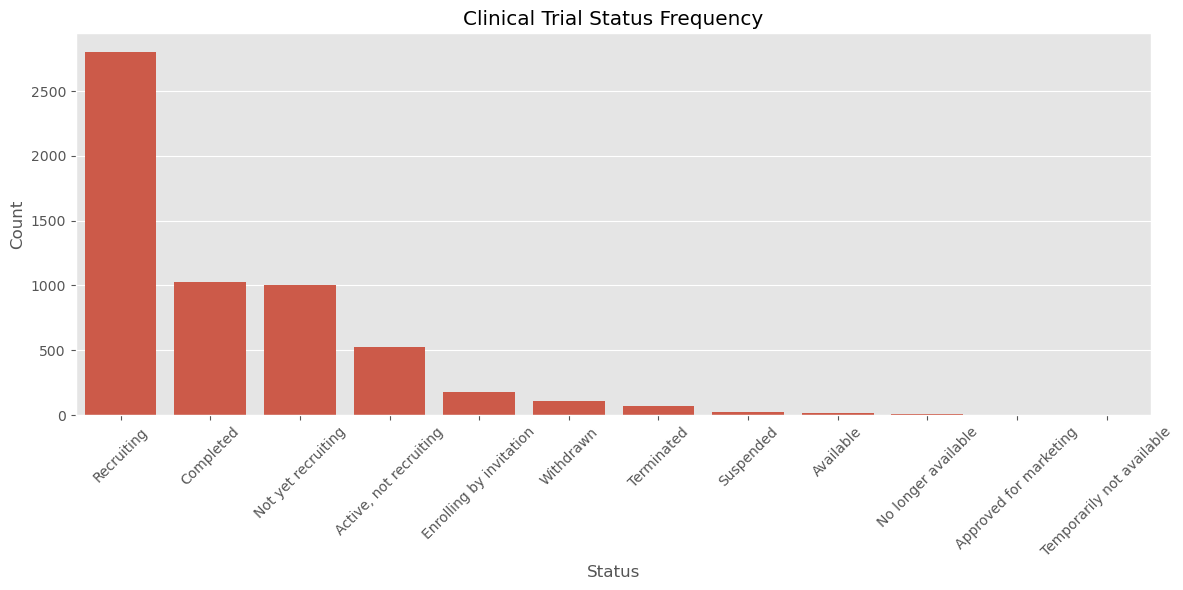

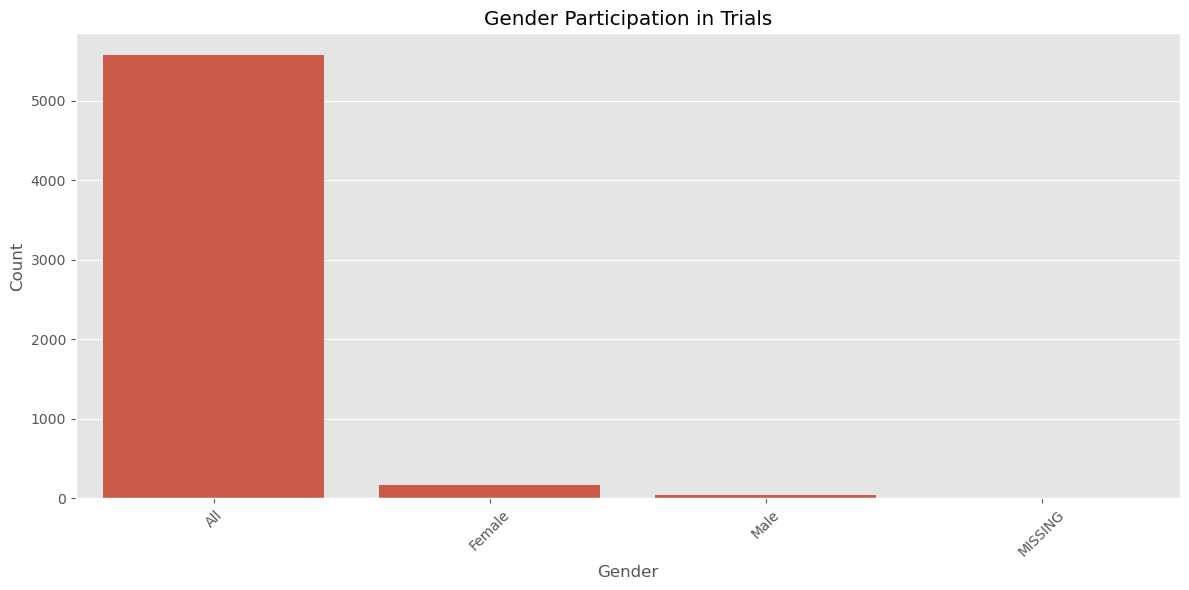

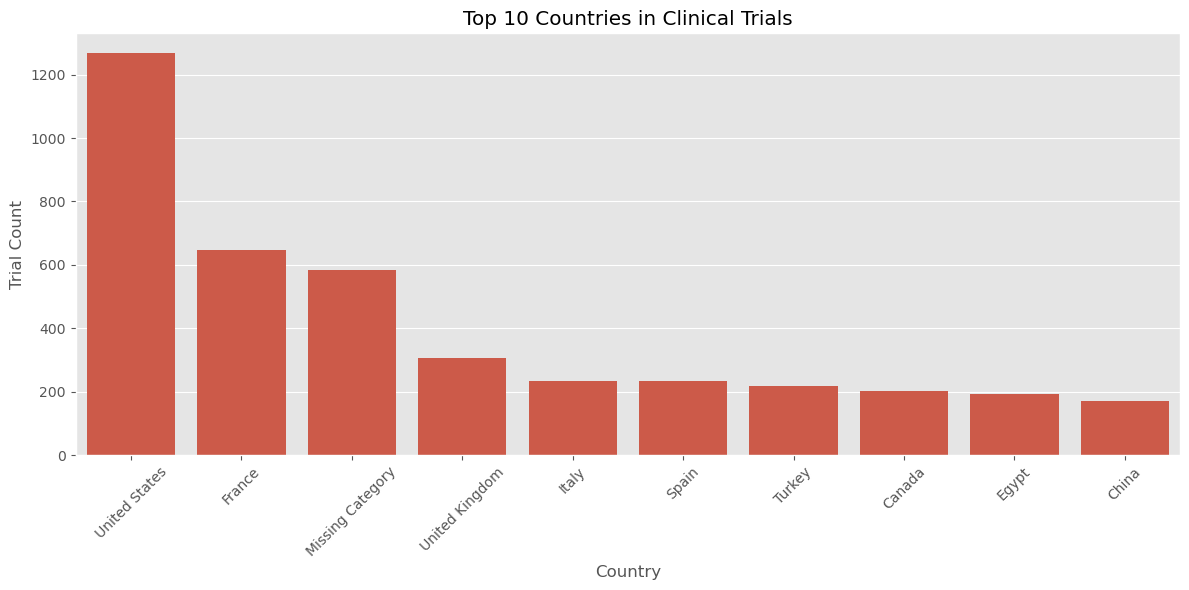

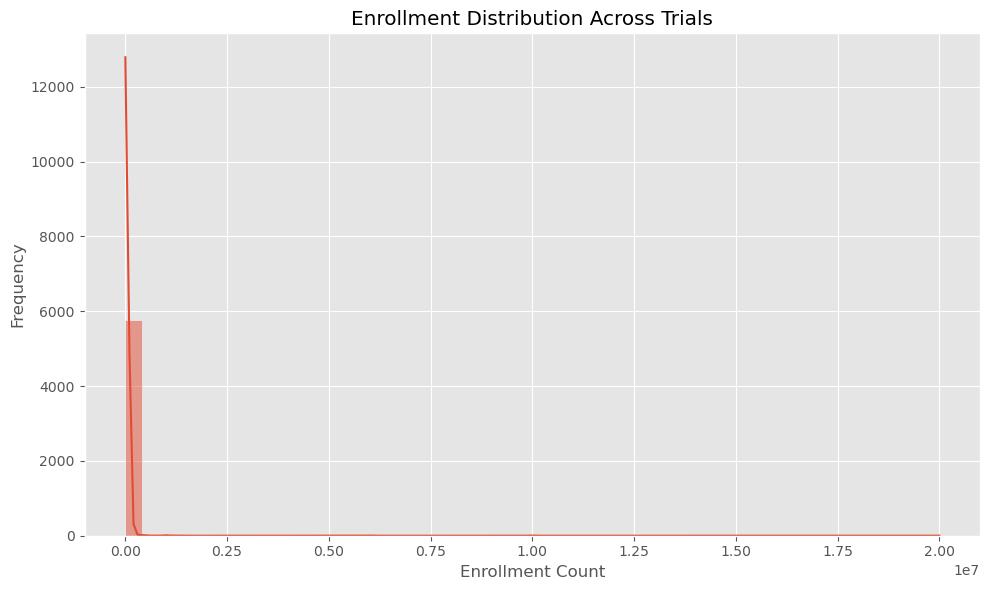

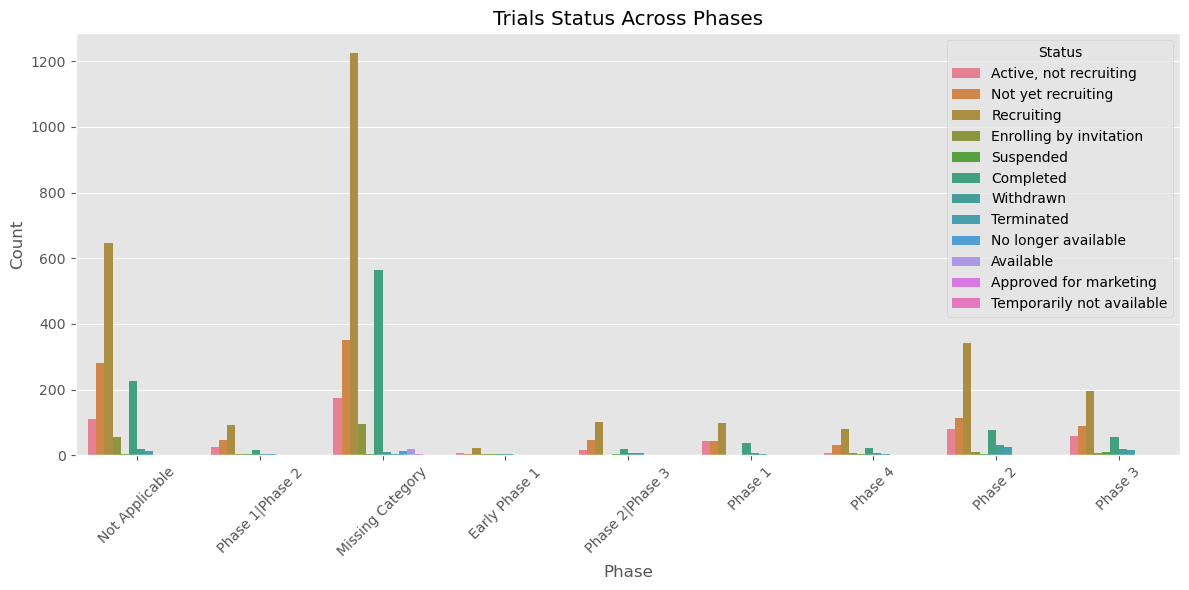

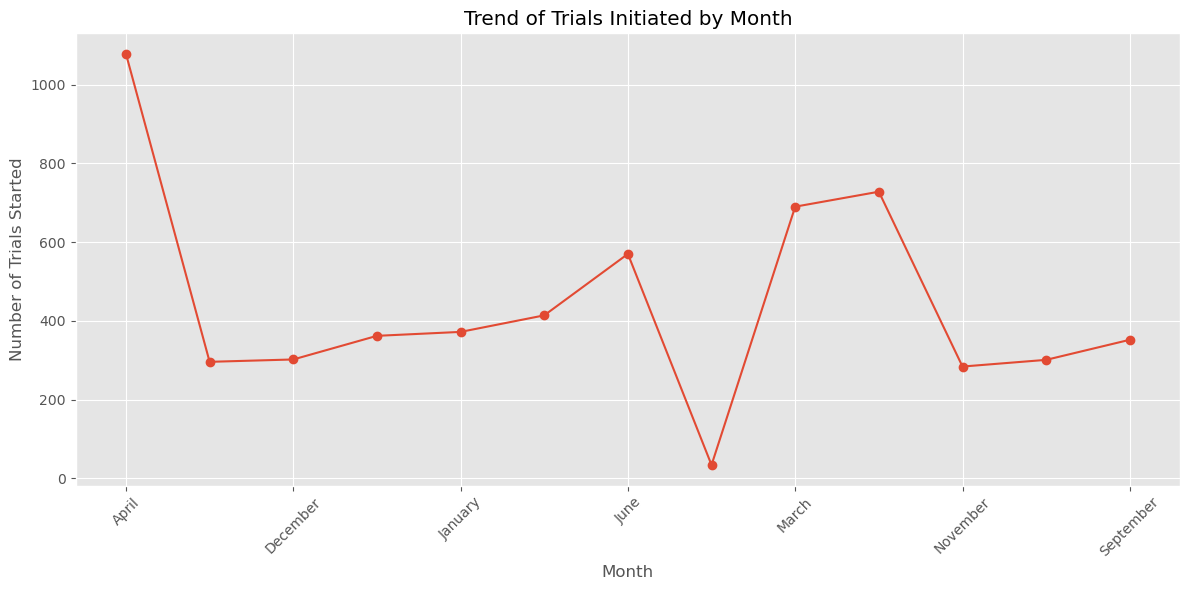

In [ ]:
#========================================================================================================================================================
#                                               Project: COVID-19 Clinical Trials EDA using Pandas
#                                               Objective: Explore patterns and insights from global clinical trial data     
#                                               Dataset Source: ClinicalTrials.gov (CSV extract)
#                                               Author: Mohammad Iqbal Hurrah
#=====================================================LOAD DATASET=========================================================================================================
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

##========================================================================================================================================================

df = pd.read_csv("COVID clinical trials.csv")

# Quick structural overview
print("\nDATASET SUMMARY\n")
print(df.info())              # schema + null counts + dtype
print("\nNumeric Summary\n")
print(df.describe())
print("\nCategorical Summary\n")
print(df.describe(include='object'))

# ========================================================== PREVIEW INITIAL DATA ======================================================================================
print("\nFirst 5 rows:\n")
print(df.head())
print("\nLast 5 rows:\n")
print(df.tail())

# ============================================================= MISSING VALUE TREATMENT========================================================================================================================================================
# For selected categorical columns where nulls are meaningful

missing_percentage = df.isnull().mean()*100 #calculate missing value percentage

cols_to_drop = missing_percentage[missing_percentage>70].index    #take columns with missing percentage rate >70
df.drop(columns = cols_to_drop,inplace=True)             #drop those columns 

categorical_to_impute = ['Acronym','Interventions','Phases','Locations']    #Categorical columns having missing/null values
df[categorical_to_impute] = df[categorical_to_impute].fillna("Missing Category") #filling nulls

# Enrollment is numeric + skewed heavily → median suits imputation
enrollment_median = df['Enrollment'].median() #extract enrollment column median
df['Enrollment'] = df['Enrollment'].fillna(enrollment_median) #fill missing values with median value 

# Remaining sparse nulls replaced uniformly for consistency
df.fillna("MISSING", inplace=True)

print("\nAfter cleaning, missing count per column:")
print(df.isnull().sum()) #Data Cleaned

#========================================================================================================================================================

#================================================================VISUALIZATION PLOTS========================================================================================
# Create Country column before using value_counts
df['Country'] = df['Locations'].astype(str).apply(lambda x: x.split(',')[-1].strip())
top_countries = df['Country'].value_counts().head(10)
plt.style.use("ggplot")
# Trial status distribution
status_dist = df['Status'].value_counts()

# Gender inclusion distribution
gender_dist = df['Gender'].value_counts()

#=========================================================================STATUS CATEGORY===============================================================================
plt.figure(figsize=(12,6))
sns.barplot(x=status_dist.index, y=status_dist.values)
plt.title("Clinical Trial Status Frequency")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
# The distribution shows that 'Completed' trials are dominant.
# This suggests most studies have finished execution,
# which reflects the late-pandemic stabilization period.
# Active but not recruiting count being high indicates 
# that follow-ups & regulatory steps are ongoing.
#=========================================================================================================================================================

#==================================================================GENDER DISTRIBUTION======================================================================================
plt.figure(figsize=(12,6))
sns.barplot(x=gender_dist.index, y=gender_dist.values)
plt.title("Gender Participation in Trials")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
# Majority of clinical trials include all genders,
# confirming balanced participant eligibility.
# Very small portion of women-only/male-only trials suggests 
# that COVID-19 research remained largely generalized
# rather than gender-specific.
#===================================================================================================================================================================

#======================================================================COUNTRY DISTRIBUTION==================================================================================
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries in Clinical Trials")
plt.xlabel("Country")
plt.ylabel("Trial Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
# United States has the largest number of trials, reflecting
# its medical research infrastructure and funding capacity.
# European countries follow, indicating global coordination
# toward COVID-19 responses during the pandemic peak.

#++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++END OF PROJECT+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

#=========================================================================================================================================================
#                                                             ADDITIONAL ANALYSIS
#=========================================================================================================================================================
#===========================================================ADVANCE EDA ANALYSIS=================================================================================
plt.figure(figsize=(10,6))
sns.histplot(df['Enrollment'], bins=50, kde=True)
plt.title("Enrollment Distribution Across Trials")
plt.xlabel("Enrollment Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Insight:
# Enrollment distribution is right-skewed,
# meaning few trials recruited very large participants
# while most studies ran with smaller groups.
# Median imputation earlier was justified.
#==========================================================================================================================================================

#================================================================TRIAL STATUS VS PHASE (CATEGORICAL COMPARISON)=============================================
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Phases', hue='Status')
plt.title("Trials Status Across Phases")
plt.xlabel("Phase")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
# Phase 3 and Phase 4 trials show higher completion rates,
# as late-stage trials are typically more structured & well-funded.
# Early phase trials have more withdrawn or unknown statuses
# indicating research uncertainty during early pandemic.
#=========================================================================================================================================================

#==============================================TRAILS TREND BY MONTH (TIME-SERIES UNDERSTANDING)========================================================
df['Start_Month'] = df['Start Date'].astype(str).apply(lambda x: x.split(" ")[0])

monthly_count = df['Start_Month'].value_counts().sort_index()

plt.figure(figsize=(12,6))
monthly_count.plot(kind='line', marker='o')
plt.title("Trend of Trials Initiated by Month")
plt.xlabel("Month")
plt.ylabel("Number of Trials Started")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Insight:
# March–May months show peak in new trial start counts.
# This period aligns with initial pandemic escalation
# prompting accelerated clinical research responses worldwide.
#========================================================================================================================================================


         NCT Number                                              Title  \
count          5783                                               5783   
unique         5783                                               5775   
top     NCT04785898  Study Assessing Vagus Nerve Stimulation in CoV...   
freq              1                                                  2   

                 Acronym      Status         Study Results Conditions  \
count               5783        5783                  5783       5783   
unique              2339          12                     2       3067   
top     Missing Category  Recruiting  No Results Available   COVID-19   
freq                3303        2805                  5747        720   

           Interventions Outcome Measures  \
count               5783             5783   
unique              4338             5688   
top     Missing Category          MISSING   
freq                 886               35   

                          Sponsor/Col